# Data-Splitting Protocol

Demonstrates and checks `src/deployment_reliability/splits.py` (DESIGN.md §10.5): partitioning a dataset into combiner-fit / threshold-calibration / held-out-test splits.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import torch

sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))
torch.manual_seed(0)
%matplotlib inline

from deployment_reliability.splits import three_way_split

## Check 1 — Split sizes and disjointness (figure)

Mirrors an ImageNet-1k-val-sized split (50,000 images) at the DESIGN.md 10.5 ratios (40% / 10% / 50%).

combiner-fit    n= 20000  (40.0%)
threshold-cal   n=  5000  (10.0%)
held-out test   n= 25000  (50.0%)


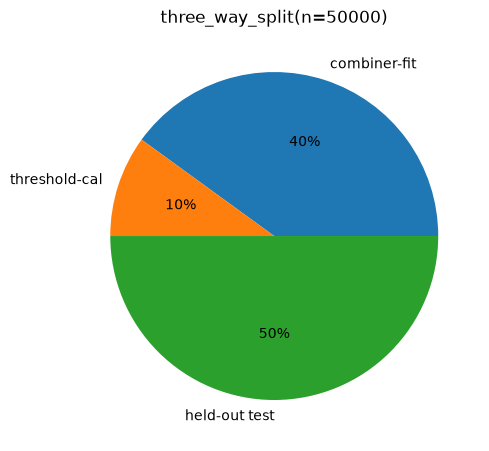

PASSED: splits are disjoint, exhaustive, and correctly sized


In [2]:
n = 50_000
combiner_idx, threshold_idx, test_idx = three_way_split(n, ratios=(0.4, 0.1, 0.5), seed=42)
sizes = {"combiner-fit": len(combiner_idx), "threshold-cal": len(threshold_idx), "held-out test": len(test_idx)}
for name, size in sizes.items():
    print(f"{name:15s} n={size:6d}  ({size / n:.1%})")

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(sizes.values(), labels=sizes.keys(), autopct="%1.0f%%", colors=["tab:blue", "tab:orange", "tab:green"])
ax.set_title(f"three_way_split(n={n})")
plt.tight_layout(); plt.show()

all_idx = torch.cat([combiner_idx, threshold_idx, test_idx])
assert len(all_idx.unique()) == n, "splits must be disjoint and exhaustive"
assert sizes["combiner-fit"] == 20000 and sizes["threshold-cal"] == 5000 and sizes["held-out test"] == 25000
print("PASSED: splits are disjoint, exhaustive, and correctly sized")

### Why these ratios, not some other split

The 40/10/50 split isn't an arbitrary convention — each share matches what its stage actually needs (DESIGN.md §10.5). Combiner-fit gets the largest share (20,000 images) because a logistic-regression fit over 5 features, while cheap to train, benefits from enough data to make weight estimates stable rather than sensitive to which images happened to be sampled — notebook 02 fits an equivalent model on just 800 points and already recovers a stable weight structure, so 20,000 is comfortably beyond the point of diminishing returns for parameter stability. Threshold-calibration gets the smallest share (5,000) deliberately, since fitting one or two scalar thresholds (04) needs far less data than fitting five regression weights — mostly a handful of order statistics near the threshold boundary. The remaining half (25,000) is reserved as held-out test specifically because it's the only split whose numbers are allowed to appear in a reported result: any image that touched fitting or calibration can't also be used to report accuracy or risk without inflating it. The disjointness assertion (`len(all_idx.unique()) == n`) is the one check standing between this protocol and silent data leakage — it's a cheap, boring-looking check guarding the single most damaging failure mode a real-data evaluation notebook could have.

## Check 2 — Reproducibility and independence of the seed

In [3]:
a = three_way_split(1000, seed=7)
b = three_way_split(1000, seed=7)
c = three_way_split(1000, seed=8)

same_seed_identical = all(torch.equal(x, y) for x, y in zip(a, b))
diff_seed_identical = all(torch.equal(x, y) for x, y in zip(a, c))
print(f"same seed  -> identical splits: {same_seed_identical}")
print(f"diff seed  -> identical splits: {diff_seed_identical}")

assert same_seed_identical, "same seed must reproduce the same split"
assert not diff_seed_identical, "different seeds should (essentially always) differ"
print("PASSED")

same seed  -> identical splits: True
diff seed  -> identical splits: False
PASSED


### Why both properties are needed, not just one

Reproducibility under a fixed seed and divergence across different seeds are both load-bearing for different reasons. Same-seed reproducibility means a specific fitted combiner/threshold pair (and every number derived from it) can be regenerated exactly for debugging or for reporting in a paper — without it, "re-run this notebook" wouldn't be verifiable. Different-seed divergence matters just as much: if a real evaluation's headline AURC or ECE number happened to depend heavily on which particular 40/10/50 partition was drawn, that would be a sign the held-out test split was too small or the metric too noisy to trust from a single seed — running the same fit/calibrate/test protocol across a handful of seeds and checking the numbers don't swing wildly is the practical way to catch that, and it's only possible because different seeds are guaranteed to actually produce different partitions rather than silently collapsing to the same one.

## Summary

- `three_way_split` produces disjoint, exhaustive, correctly-proportioned partitions at exactly the DESIGN.md §10.5 ratios (40/10/50), and each ratio maps to a concrete reason (parameter count for the fit, order-statistic needs for the thresholds, integrity of the final reported numbers) rather than an arbitrary convention.
- Splits are exactly reproducible given a seed, and differ across seeds — the combination that makes both "regenerate this exact result" and "check this result isn't a lucky split" possible.

This is the least visually interesting notebook in the pipeline — no risk-coverage curves, no calibration corrections — but the property it checks (disjointness) is the one every later real-data notebook's numbers silently depend on. A leak here wouldn't cause an error anywhere downstream; it would just quietly inflate every accuracy, AURC, and ECE number reported from combiner-fit through held-out test, with no assertion elsewhere positioned to catch it. That's why it gets checked directly and explicitly here rather than assumed.

This closes the loop on the DESIGN.md §4 pipeline: features (01) → combiner (02) → calibration (03) → router (04), all fit/evaluated under this splitting protocol (05).